<h1 align='center'>Домашнее задание</h1>

**Дополнительный материал для выполнения дз**:

- Лекция Coursera: https://www.coursera.org/learn/machine-learning?specialization=machine-learning-introduction#modules
s (Week 3 Regularized logistic regression)
- Статья на Хабре: https://habrahabr.ru/company/io/blog/265007/
- Книжка ISLR, 4 глава: http://www-bcf.usc.edu/~gareth/ISL/ISLR%20First%20Printing.pdf
- Логистическая регрессия, UFLDL Tutorial: http://ufldl.stanford.edu/tutorial/supervised/LogisticRegression/
- Линейная регрессия, UFLDL Tutorial: http://ufldl.stanford.edu/tutorial/supervised/LinearRegression/


<h1 align='center'>Logistic Regression</h1>

In [33]:
import pandas as pd
import numpy as np
import tqdm # interactive progress bar

import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

%matplotlib inline

# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Знакомство с данными
Данные представляют собой выборку отзывов о еде с сайта Амазон. Для них проставлены метки -- положительный или отрицательный отзыв.

In [34]:
train_df = pd.read_csv('./data/train.csv')

In [35]:
print(train_df.shape)

(110163, 3)


In [36]:
train_df.Prediction.value_counts(normalize=True)

Prediction
0    0.50074
1    0.49926
Name: proportion, dtype: float64

Видим, что классы сбалансированы. Можем оценивать качество модели по метрике ```accuracy```.

In [37]:
train_df.head()

,ID,Reviews_Summary,Prediction
0,239071,Michigan Cherries,1
1,466160,Great Product,1
2,397133,Ovaltine,1
3,297146,~,1
4,292685,Love it!,1


In [38]:
train_df.tail()

,ID,Reviews_Summary,Prediction
110158,486256,Terrible!,0
110159,199050,"Cheap Coffee, No Banana Flavor",0
110160,278179,Not as described,0
110161,87500,Tastes like a squirt of toothpaste mixed into ...,0
110162,121963,Disappointed,0



----------
## 2. Извлечение признаков
Для решения задачи классификации необходимо преобразовать каждый отзыв (документ) в вектор. Размерность данного вектора будет равна количеству слов используемых в корпусе (все документы). Каждая координата соответствует слову, значение в координате равно количеству раз, слово используется в документе. 

Для решения данной задачи напишем код, который преобразовывает матрицу документов в численную матрицу.

Дополнительная информация:

- Подробнее про векторное представление документов: http://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction
- Разряженные матрицы: http://www.scipy-lectures.org/advanced/scipy_sparse/
- Трансформер: http://scikit-learn.org/stable/modules/feature_extraction.html#common-vectorizer-usage
- Подробнее про разреженные матрицы: http://docs.scipy.org/doc/scipy-0.14.0/reference/sparse.html
- Hashing trick: https://en.wikipedia.org/wiki/Feature_hashing

Помните, что все эти трансформеры возвращают ```sparse```-матрицы. Учитывая это и то, что линейные модели достаточно хорошо масштабируются на большое количество фич, можно смело ставить ```n_features``` 1000+.

In [39]:
review_summaries = list(train_df['Reviews_Summary'].values)
review_summaries = [l.lower() for l in review_summaries]

In [40]:
review_summaries[:5]

['michigan cherries', 'great product', 'ovaltine', '~', 'love it!']

Преобразуем ```review_summaries``` с помощью ```TfidfVectorizer```.

In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [42]:
vectorizer = TfidfVectorizer()

In [43]:
tfidfed = vectorizer.fit_transform(review_summaries)

In [44]:
from sklearn.model_selection import train_test_split

In [45]:
X = tfidfed
y = train_df.Prediction.values
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=42)

## 3. Логистическая регрессия

Логистическая регрессия -- линейный классификатор, который очень часто используется на практике, например, в кредитном скоринге. Преимущества этой модели -- скорость обучения и предсказания (даже при сотнях тысяч фичей) а также интепретируемость: важные признаки имеют бОльшие по модулю веса. 

При этом отрицательные веса говорят, что фича важна для определения класса 0, а положительные -- для определения класса 1. Это можно понять, если вспомнить, что разделяющая поверхность линейных моделей, это $w^Tx = 0$, а значение алгоритма есть $a(x) = sign(w^Tx)$.

Будем предсказывать сентимент, подготовим данные и сделаем валидационную выборку. При этом нужно оценивать качество модели не по обучающей выборке, а по валидационной. Иначе вы переобучитесь, когда будете тюнить гиперпараметры модели.

-----
** Реализуйте код в модуле ```dmia.classifiers.logistic_regression```.**

-----

In [46]:
from dmia.gradient_check import *
from dmia.classifiers import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

## Gradient check

В этой ячейке вы можете проверить, правильно ли у вас все работает, прежде чем обучать модель на всех данных.

In [47]:
X_train_sample = X_train[:100000]
y_train_sample = y_train[:100000]
clf = LogisticRegression()
clf.w = np.random.randn(X_train_sample.shape[1]+1) * 2
loss, grad = clf.loss(LogisticRegression.append_biases(X_train_sample), y_train_sample, 0.0)

# Numerically compute the gradient along several randomly chosen dimensions, and
# compare them with your analytically computed gradient. The numbers should match
# almost exactly along all dimensions.
f = lambda w: clf.loss(LogisticRegression.append_biases(X_train_sample), y_train_sample, 0.0)[0]
grad_numerical = grad_check_sparse(f, clf.w, grad, 10)

<string>:16: RuntimeWarning: invalid value encountered in scalar divide


numerical: 0.000000 analytic: 0.000000, relative error: nan
numerical: -0.000006 analytic: -0.000006, relative error: 2.27e-07
numerical: -0.000003 analytic: -0.000003, relative error: 1.76e-06
numerical: 0.000004 analytic: 0.000004, relative error: 7.67e-08
numerical: -0.000054 analytic: -0.000054, relative error: 2.53e-08
numerical: 0.000020 analytic: 0.000020, relative error: 1.18e-07
numerical: -0.000099 analytic: -0.000099, relative error: 3.92e-09
numerical: 0.000008 analytic: 0.000008, relative error: 2.15e-07
numerical: -0.000012 analytic: -0.000012, relative error: 2.48e-07
numerical: -0.000008 analytic: -0.000008, relative error: 2.42e-07


Обучите свою модель на ```X_train, y_train```.

Для начала можете взять параметры по умолчанию, и найти оптимальные используя валидацию.

In [48]:
clf = LogisticRegression()

iteration 0 / 5000: loss 0.484628
iteration 100 / 5000: loss 0.479965
iteration 200 / 5000: loss 0.458702
iteration 300 / 5000: loss 0.472939
iteration 400 / 5000: loss 0.446848
iteration 500 / 5000: loss 0.484248
iteration 600 / 5000: loss 0.447270
iteration 700 / 5000: loss 0.438006
iteration 800 / 5000: loss 0.442825
iteration 900 / 5000: loss 0.459984
iteration 1000 / 5000: loss 0.446124
iteration 1100 / 5000: loss 0.433773
iteration 1200 / 5000: loss 0.440069
iteration 1300 / 5000: loss 0.455555
iteration 1400 / 5000: loss 0.401483
iteration 1500 / 5000: loss 0.440402
iteration 1600 / 5000: loss 0.412026
iteration 1700 / 5000: loss 0.422969
iteration 1800 / 5000: loss 0.463341
iteration 1900 / 5000: loss 0.423509
iteration 2000 / 5000: loss 0.400924
iteration 2100 / 5000: loss 0.417470
iteration 2200 / 5000: loss 0.427069
iteration 2300 / 5000: loss 0.426324
iteration 2400 / 5000: loss 0.379090
iteration 2500 / 5000: loss 0.406956
iteration 2600 / 5000: loss 0.421954
iteration 270

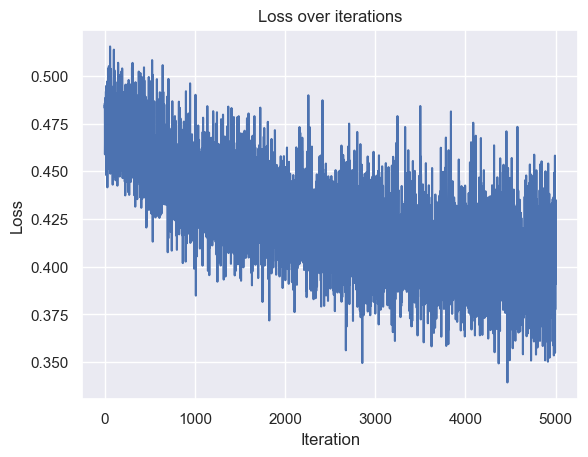

In [54]:
clf.train(X_train, y_train,
          learning_rate=0.5,
          reg=1e-4,
          num_iters=5000,
          batch_size=256,
          verbose=True) 
import matplotlib.pyplot as plt
plt.plot(clf.loss_history)
plt.title("Loss over iterations")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


           # печатает каждые 100 итераций



Посмотрим на качество на валидации.

In [55]:
print("Train f1-score = %.3f" % accuracy_score(y_train, clf.predict(X_train)))
print("Test f1-score = %.3f" % accuracy_score(y_test, clf.predict(X_test)))

Train f1-score = 0.858
Test f1-score = 0.851


Нарисуем кривые обучения.

In [56]:
clf = LogisticRegression()
train_scores = []
test_scores = []
num_iters = 1000

for i in tqdm.trange(num_iters):
    # Сделайте один шаг градиентного спуска с помощью num_iters=1
    clf.train(X_train, y_train, learning_rate=1.0, num_iters=1, batch_size=256, reg=1e-3)
    train_scores.append(accuracy_score(y_train, clf.predict(X_train)))
    test_scores.append(accuracy_score(y_test, clf.predict(X_test)))

100%|██████████| 1000/1000 [01:32<00:00, 10.87it/s]


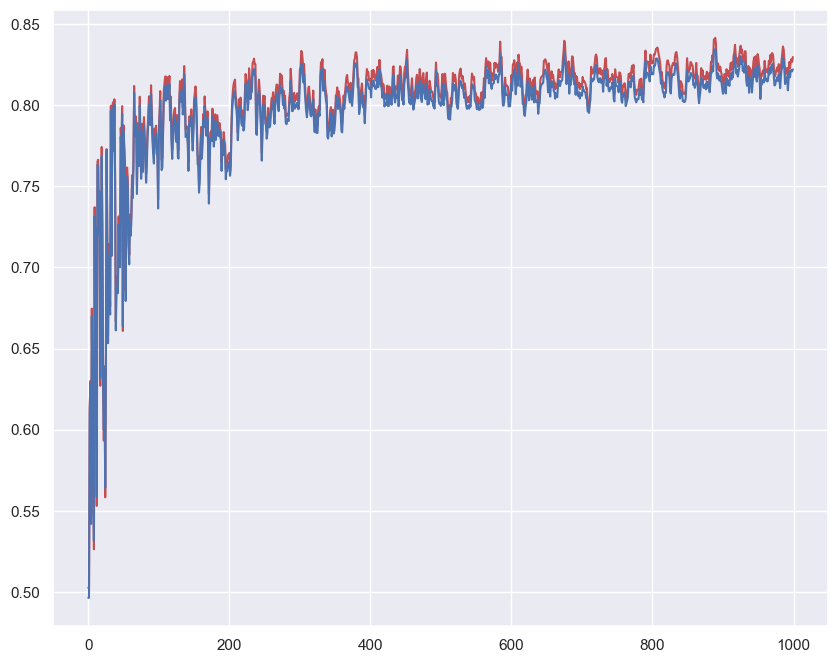

In [23]:
plt.figure(figsize=(10,8))
plt.plot(train_scores, 'r', test_scores, 'b')

## 4. Задание

* Обучим нашу модель **на всех данных**, преобразовав их через ```TfidfVectorizer``` с ```max_features=3000```.

* Параметры модели ```learning_rate=1.0, num_iters=1000, batch_size=256, reg=1e-3``` и выведем первые 5 самых важных фичей для класса 1 и 5 фичей для класса 0. Убедимся, что они коррелируют с вашей интуицией о хороших/плохих отзывах. 

**Hint:** зная индекс фичи, само слово вы можете получить, используя метод ```vectorizer.get_feature_names()```.

**Hint:** ```np.argsort```.

In [60]:
# Обучите модель
vectorizer = TfidfVectorizer(max_features=3000)
X = vectorizer.fit_transform(review_summaries)
y = train_df.Prediction.values
clf = LogisticRegression()
clf.train(X, y, verbose=True, learning_rate=0.5, num_iters=5000, batch_size=256, reg=1e-4)


iteration 0 / 5000: loss 0.693043
iteration 100 / 5000: loss 0.650900
iteration 200 / 5000: loss 0.626326
iteration 300 / 5000: loss 0.595254
iteration 400 / 5000: loss 0.594068
iteration 500 / 5000: loss 0.549697
iteration 600 / 5000: loss 0.551544
iteration 700 / 5000: loss 0.540833
iteration 800 / 5000: loss 0.531367
iteration 900 / 5000: loss 0.483484
iteration 1000 / 5000: loss 0.492633
iteration 1100 / 5000: loss 0.491607
iteration 1200 / 5000: loss 0.496924
iteration 1300 / 5000: loss 0.491398
iteration 1400 / 5000: loss 0.495671
iteration 1500 / 5000: loss 0.475308
iteration 1600 / 5000: loss 0.484619
iteration 1700 / 5000: loss 0.451863
iteration 1800 / 5000: loss 0.472120
iteration 1900 / 5000: loss 0.483764
iteration 2000 / 5000: loss 0.434543
iteration 2100 / 5000: loss 0.418592
iteration 2200 / 5000: loss 0.461312
iteration 2300 / 5000: loss 0.455553
iteration 2400 / 5000: loss 0.429870
iteration 2500 / 5000: loss 0.408535
iteration 2600 / 5000: loss 0.450143
iteration 270

In [61]:

# Получите индексы фичей
pos_features = np.argsort(clf.w)[-5:]
neg_features = np.argsort(clf.w)[:5]

In [62]:
# Выведите слова
fnames = vectorizer.get_feature_names_out()
print([fnames[p] for p in pos_features])
print([fnames[n] for n in neg_features])

['excellent', 'delicious', 'love', 'best', 'great']
['not', 'bad', 'disappointed', 'terrible', 'but']


## 5. Сравнение с sklearn.linear_model.LogisticRegression

Обучите такую же модель, но из пакета ```sklearn.linear_model``` и убедитесь, что ваша имплементация ничем не хуже (ну или почти не хуже).

In [65]:
from sklearn.linear_model import SGDClassifier

In [66]:
clf = SGDClassifier(loss="log_loss", penalty="l2", alpha=1e-3,
    eta0=1.0,     learning_rate="constant",    max_iter=1000,
    random_state=42
)
clf.fit(X_train, y_train)

,loss,'log_loss'
,penalty,'l2'
,alpha,0.001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [67]:
print("Train accuracy = %.3f" % accuracy_score(y_train, clf.predict(X_train)))
print("Test accuracy = %.3f" % accuracy_score(y_test, clf.predict(X_test)))

Train accuracy = 0.816
Test accuracy = 0.812
